# **U-Net 모델 구현**

✅ 아래 코드는 PyTorch로 작성한 간단한 U-Net 모델입니다.

✅ 주요 목표: 작은 이미지 세트로 segmentation 학습을 테스트하기!

✅ 특징: 업샘플링(deconv/upsample 선택 가능), 입력 스케일링, Gaussian noise 추가, 배치 정규화 적용

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# --- 작은 U-Net 정의 ---
class UNetSmall(nn.Module):
    def __init__(self, upsample_mode='deconv', net_scaling=None, edge_crop=0, gaussian_noise_std=0.1):
        super().__init__()
        self.net_scaling = net_scaling
        self.edge_crop = edge_crop
        self.gaussian_noise_std = gaussian_noise_std
        self.upsample_mode = upsample_mode

         # Convolution Block: Conv -> ReLU -> Conv -> ReLU
        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.ReLU(inplace=True)
            )

        # 인코더 부분 목표 -> 128 까지!
        self.enc1 = conv_block(3, 16)
        self.enc2 = conv_block(16, 32)
        self.enc3 = conv_block(32, 64)
        self.enc4 = conv_block(64, 128)
        # Bottleneck
        self.center = conv_block(128, 128)
        self.pool = nn.MaxPool2d(2)


        # 업샘플링 부분 정의 (deconv 또는 upsample+conv) 로
        if upsample_mode == 'deconv':
            def upsample_layer(in_c, out_c):
                return nn.ConvTranspose2d(in_c, out_c, kernel_size=2, stride=2)
        else:
            def upsample_layer(in_c, out_c):
                return nn.Sequential(
                    nn.Upsample(scale_factor=2, mode='nearest'),
                    nn.Conv2d(in_c, out_c, 1)
                )
        # 디코더 부분
        self.up4 = upsample_layer(128, 64)
        self.dec4 = conv_block(192, 64)
        self.up3 = upsample_layer(64, 32)
        self.dec3 = conv_block(96, 32)
        self.up2 = upsample_layer(32, 16)
        self.dec2 = conv_block(48, 16)
        self.up1 = upsample_layer(16, 8)
        self.dec1 = conv_block(24, 8)

        # 최종 출력: 1채널(segmentation mask)
        self.final = nn.Conv2d(8, 1, kernel_size=1)

    def forward(self, x):
        if self.net_scaling:
        # 입력 스케일링
            x = F.avg_pool2d(x, self.net_scaling)
        # Gaussian noise 추가
        if self.gaussian_noise_std:
            noise = torch.randn_like(x) * self.gaussian_noise_std
            x = x + noise

        # 배치 정규화 적용
        x = F.batch_norm(x, running_mean=None, running_var=None, training=True)

        # 인코더
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        # Bottleneck
        center = self.center(self.pool(e4))

        # 디코더 + Skip Connection
        d4 = self.up4(center)
        d4 = torch.cat((d4, e4), dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat((d3, e3), dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat((d2, e2), dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat((d1, e1), dim=1)
        d1 = self.dec1(d1)

        out = self.final(d1)
        out = torch.sigmoid(out)
         # Crop + Pad
        if self.edge_crop > 0:
            out = out[:, :, self.edge_crop:-self.edge_crop, self.edge_crop:-self.edge_crop]
            out = F.pad(out, (self.edge_crop, self.edge_crop, self.edge_crop, self.edge_crop))
        # Upsample 다시 확대
        if self.net_scaling:
            out = F.interpolate(out, scale_factor=self.net_scaling, mode='nearest')

        return out


## **학습용 데이터 생성하기**

In [16]:
batch_size = 32
x = torch.randn(batch_size, 3, 128, 128)  # RGB 이미지
y = (torch.rand(batch_size, 1, 128, 128) > 0.5).float()  # 랜덤 이진 마스크

dataset = TensorDataset(x, y)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

## **데이터 시각화**

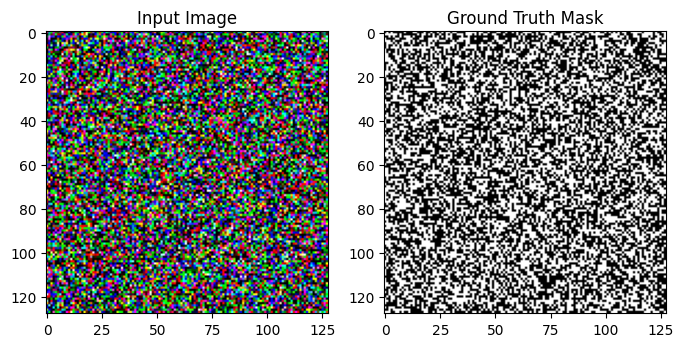

In [17]:
import matplotlib.pyplot as plt
# 첫 번째 이미지를 시각화
sample_x = x[0]
sample_y = y[0]

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(sample_x.permute(1, 2, 0).numpy())
plt.title('Input Image')

plt.subplot(1, 2, 2)
plt.imshow(sample_y.squeeze().numpy(), cmap='gray')
plt.title('Ground Truth Mask')
plt.show()

## **모델 선언 및 학습**

In [18]:
# --- 모델 선언 및 학습 ---
model = UNetSmall(upsample_mode='deconv', net_scaling=None, edge_crop=0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCELoss()

# 간단히 30 epoch만
for epoch in range(10):
    model.train()
    total_loss = 0
    for xb, yb in loader:
        pred = model(xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(loader):.4f}")

Epoch 1, Loss: 0.6938
Epoch 2, Loss: 0.6932
Epoch 3, Loss: 0.6932
Epoch 4, Loss: 0.6931
Epoch 5, Loss: 0.6931
Epoch 6, Loss: 0.6931
Epoch 7, Loss: 0.6931
Epoch 8, Loss: 0.6930
Epoch 9, Loss: 0.6930
Epoch 10, Loss: 0.6930


## **아래 주석을 풀고 U-Net 모델에 대해 간단히 설명해주세요 😀**

[답변]


---

U-Net은 바이오 메디컬 이미지 분할을 위한 합성곱 신경망이다.

U-Net은 이미 검증이 끝난 패치는 건너뛰기 때문에 속도가 빠르고, 컨텍스트 인식과 지역화 트레이드오프 문제를 개선했다는 특징이 있다.

U-Net은 FCN을 기반으로 구축되었으며, 컨텍스트를 포착하는 수축 경로와 특성 맵을 업 샘플링하고 수축 경로에서 포착한 특성 맵의 컨텍스트와 결합하여 정확한 지역화를 수행하는 확장 경로로 구성되어 있다.
U-Net의 합성곱 블록은 각 3x3 합성곱 두 개로 구성되어 있고, 그 사이에 드롭아웃이 존재한다. 수축경로에서의 블록은 각 블록에서 최대 풀링을 이용하여 크기를 줄이며 다음 블록으로 넘어간다.

확장 경로에서는 합성곱 블록에 up-conv를 앞에 붙여 수축 과정에서 줄어든 크기를 다시 키우며 합성곱 블록을 이용하는 형태를 이룬다.

쿠기가 다양한 이미지의 객체를 분할하기 위해 크기가 다양한 특성 맵을 병합할 수 있도록 다운 샘플링과 업 샘플링을 순서대로 반복하는 구조이다.

## **아래 주석을 풀고 DeepLabv1, v2, v3. v3+  모델에 대해 각각 간단히 설명해주세요 🐶**

[답변]


---

**[DeepLab v1]**

DeepLab v1은 심층 합성 신경망을 이용한 세맨틱 이미지 분할(Semantic Segmentation) 모델이다. DeepLab v1은 Atrous 합성곱을 사용하여 해상도를 유지하면서 넓은 수용 영역을 확보하고, Fully Connected CRF(Conditional Random Field)를 결합해 경계 정보를 정교하게 복원한다는 특징이 있다. 고해상도 세그멘테이션을 효율적으로 수행할 수 있다.

**[DeepLab v2]**

DeepLab v2는 DeepLab v1을 개선한 모델로, ASPP(Atrous Spatial Pyramid Pooling) 구조를 도입하였다. ASPP는 서로 다른 팽창률의 합성곱을 병렬로 수행하여 여러 스케일의 컨텍스트 정보를 효과적으로 포착한다. 이를 통해 다양한 크기의 객체에 대한 분할 성능이 향상되었다.

**[DeepLab v3]**

DeepLab v3는 ASPP를 확장하고, 배치 정규화를 적용해 학습 안정성을 높였다. 또한, 이미지 전체의 컨텍스트를 반영하기 위해 전역 평균 풀링 특징(Image-level Feature)을 추가해 다양한 스케일의 정보를 더 풍부하게 활용할 수 있다.

**[DeepLab v3+]**

DeepLab v3+는 DeepLab v3의 인코더–디코더 구조를 결합한 모델이다. 인코더는 ASPP로 컨텍스트를 포착하고, 디코더는 저수준 피처(low-level feature)를 결합하여 경계 정보를 세밀하게 복원해 정확한 객체 경계와 높은 분할 성능을 얻을 수 있다.